# Attempt to use combination of two fits: accurate local and global

In [1]:
import numpy as np
import math
import torch
import gpytorch

from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import matplotlib.axes
import matplotlib.colors
import matplotlib.figure
import mpl_toolkits.mplot3d
from scipy.spatial.distance import cdist

In [2]:
n1 = 100
n2 = 5000 # sample points from broadened density

k2 = 100 # k-means points from broadened density

In [3]:


def gaussian_func(r, p, beta):
    a=5.
    b=-10.
    r0=-2
    r1=2
    p0=2
    p1=-2

    omega_r1 = 1.0
    omega_r2 = 1.0

    omega_p1 = 0.5
    omega_p2 = 0.5

    return a * np.exp(- beta*omega_r1 * (r - r0) ** 2) * np.exp(- beta*omega_p1 * (p - p0) ** 2) \
           + b * np.exp(- beta*omega_r2 * (r - r1) ** 2) * np.exp(- beta*omega_p2 * (p - p1) ** 2)

rs = -2.
ps = 2.

In [4]:
n_iter = 100

def generate_sample_points(n, beta, dx_max=5.0):
    # Calculate the normalization constant Zn for the function
    def func_norm(r, p,beta):
        return np.abs(gaussian_func(r, p,beta))

    # Monte Carlo routine to generate sample points
    sample_points = np.zeros((n,2))
    
    x_n = np.array([rs, ps])
    counter = 0
    
    for i in range(n):
        naccepts = 0.
        for j in range(n_iter):
            dx = dx_max * (2 * np.random.rand(2) - 1.)
            t_n = x_n + dx
            a_n = func_norm(*t_n, beta) / func_norm(*x_n, beta)
            if a_n > 1 or np.random.rand() < a_n:
                x_n = t_n
                naccepts += 1.
        

        if (naccepts==0):
            print('Problem: n_iter is too small and a point is replicated.')
            
        sample_points[counter] = x_n.copy()
        counter += 1
 
    return sample_points

In [5]:

X1 = generate_sample_points(n1,1.) # draw points using absolute value of true density
Y1 = gaussian_func(X1[:,0],X1[:,1], 1.) # value of function at sample points

X2 = generate_sample_points(n2,0.125) # draw from broader density
Y2 = gaussian_func(X2[:, 0], X2[:, 1], 1.)


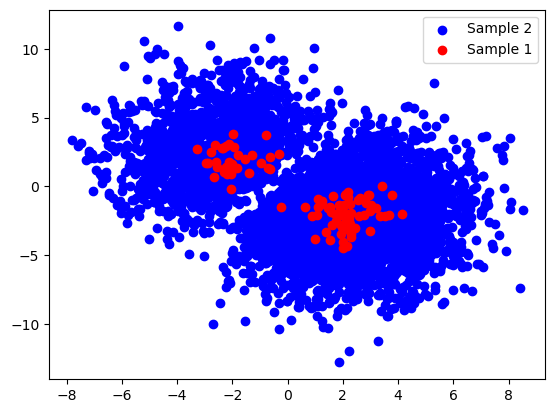

In [6]:


plt.scatter(X2[:,0], X2[:,1], c='b', label='Sample 2')
plt.scatter(X1[:,0],X1[:,1], c='r',label='Sample 1')
plt.legend()

plt.show()


In [7]:
km = KMeans(n_clusters=k2,init='random',n_init=10,max_iter=300,tol=1e-04,random_state=0)

In [8]:
x_k = km.fit_predict(X2)

In [9]:
def closest_node(node,nodes):
    return nodes[cdist([node],nodes).argmin()]


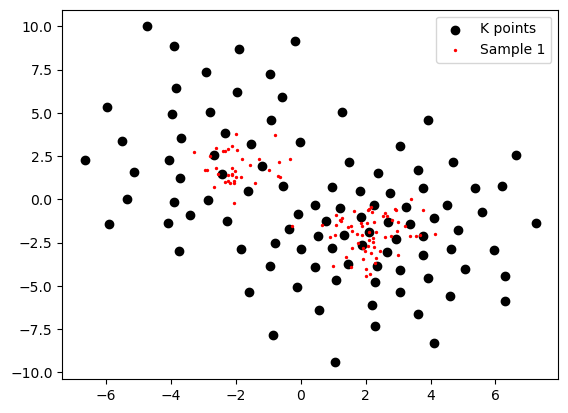

In [10]:
X0 = np.array([closest_node(km.cluster_centers_[idx], X2) for idx in range(km.n_clusters)])
Y0 = gaussian_func(X0[:, 0], X0[:, 1], 1.)


plt.scatter(X0[:,0],X0[:,1], c='black',label='K points')
plt.scatter(X1[:,0],X1[:,1], c='r',label='Sample 1',s=2)
plt.legend(scatterpoints=1)

plt.show()

In [11]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [12]:
train_x1 = torch.tensor(X1, dtype=torch.float32)
train_x0 = torch.tensor(X0, dtype=torch.float32)

train_y1 = torch.tensor(Y1, dtype=torch.float32)
train_y0 = torch.tensor(Y0, dtype=torch.float32)

In [13]:
# initialize likelihood and model
likelihood = []
model = []
optimizer = []
mll = []

likelihood.append( gpytorch.likelihoods.GaussianLikelihood() )
model.append( ExactGPModel(train_x0, train_y0, likelihood[0]) )
optimizer.append(torch.optim.Adam(model[0].parameters(), lr=0.1))
mll.append(gpytorch.mlls.ExactMarginalLogLikelihood(likelihood[0], model[0]))

likelihood.append( gpytorch.likelihoods.GaussianLikelihood() )
model.append( ExactGPModel(train_x1, train_y1, likelihood[1]) )
optimizer.append(torch.optim.Adam(model[1].parameters(), lr=0.1))
mll.append(gpytorch.mlls.ExactMarginalLogLikelihood(likelihood[1], model[1]))



In [14]:
def optimizeModel( model, mll, optimizer, train_x, train_y ):
    training_iterations = 2000
    output_counter = 20
    prevLoss = 10000.
    min_dx = 0.00001
    lossRecord = []
    for i in range(training_iterations):
        # Zero backprop gradients
        optimizer.zero_grad()
        # Get output from model
        output = model(train_x)
        # Calc loss and backprop derivatives
        loss = -mll(output, train_y)
        loss.backward()
        
        currentLoss = loss.item()
        lossRecord.append(currentLoss)
        
        dx = np.abs(prevLoss-currentLoss)/np.abs(currentLoss)
        if ( dx < min_dx):
            print(' Small change in loss of ',dx)
            break
        prevLoss = currentLoss
        
        if ((i-1)%output_counter == 0):
            print('Iter %d/%d - Loss: %.4f :  %.8f' % (
                i-1, training_iterations, loss.item(), dx
            ))
            
        optimizer.step()


    return model, lossRecord



In [15]:
model[0], lossRecord0 = optimizeModel(model[0], mll[0], optimizer[0], train_x0, train_y0)
model[0].eval()
likelihood[0].eval()

Iter 0/2000 - Loss: 1.6882 :  0.03808457
Iter 20/2000 - Loss: 1.3012 :  0.00737532
Iter 40/2000 - Loss: 1.2231 :  0.00125756
Iter 60/2000 - Loss: 1.2022 :  0.00047417
Iter 80/2000 - Loss: 1.1977 :  0.00007873
Iter 100/2000 - Loss: 1.1964 :  0.00002531
 Small change in loss of  9.469516678859084e-06


GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [16]:
model[1], lossRecord1 = optimizeModel(model[1], mll[1], optimizer[1], train_x1, train_y1)
model[1].eval()
likelihood[1].eval()

Iter 0/2000 - Loss: 1.7515 :  0.07712221
Iter 20/2000 - Loss: 0.6445 :  0.06168980
Iter 40/2000 - Loss: -0.0261 :  1.13275980
Iter 60/2000 - Loss: -0.5543 :  0.04144080
Iter 80/2000 - Loss: -0.9269 :  0.01550480
Iter 100/2000 - Loss: -1.1245 :  0.00584262
Iter 120/2000 - Loss: -1.1996 :  0.00165540
Iter 140/2000 - Loss: -1.2279 :  0.00007000
Iter 160/2000 - Loss: -1.2417 :  0.00079748
Iter 180/2000 - Loss: -1.2485 :  0.00040245
Iter 200/2000 - Loss: -1.2538 :  0.00099151
 Small change in loss of  5.227046257933825e-06


GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

<function matplotlib.pyplot.show(close=None, block=None)>

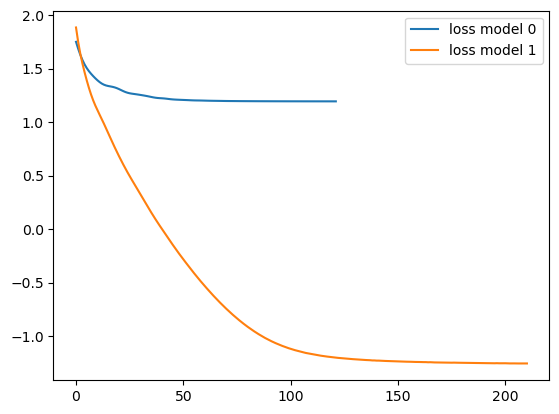

In [17]:
plt.plot(lossRecord0,label='loss model 0')
plt.plot(lossRecord1,label='loss model 1')
plt.legend()
plt.show

In [18]:
n_grid = 201
x = np.linspace(-10, 10, n_grid)
y = np.linspace(-10, 10, n_grid)
xx, yy = np.meshgrid(x, y)

X_grid = np.column_stack((xx.flatten(), yy.flatten()))
test_x = torch.tensor(X_grid, dtype=torch.float32)

y_true = gaussian_func(X_grid[:,0], X_grid[:,1],1.)
test_y = torch.tensor(y_true, dtype=torch.float32)

In [19]:
def predictModel( model, x_eval):
    with gpytorch.settings.max_preconditioner_size(10), torch.no_grad():
        with gpytorch.settings.use_toeplitz(False), gpytorch.settings.max_root_decomposition_size(30), gpytorch.settings.fast_pred_var():
            preds = model(x_eval)
    return preds


In [20]:
preds0 = predictModel( model[0], test_x)
preds1 = predictModel( model[1], test_x)

y_pred0 = preds0.mean.numpy()
y_pred1 = preds1.mean.numpy()

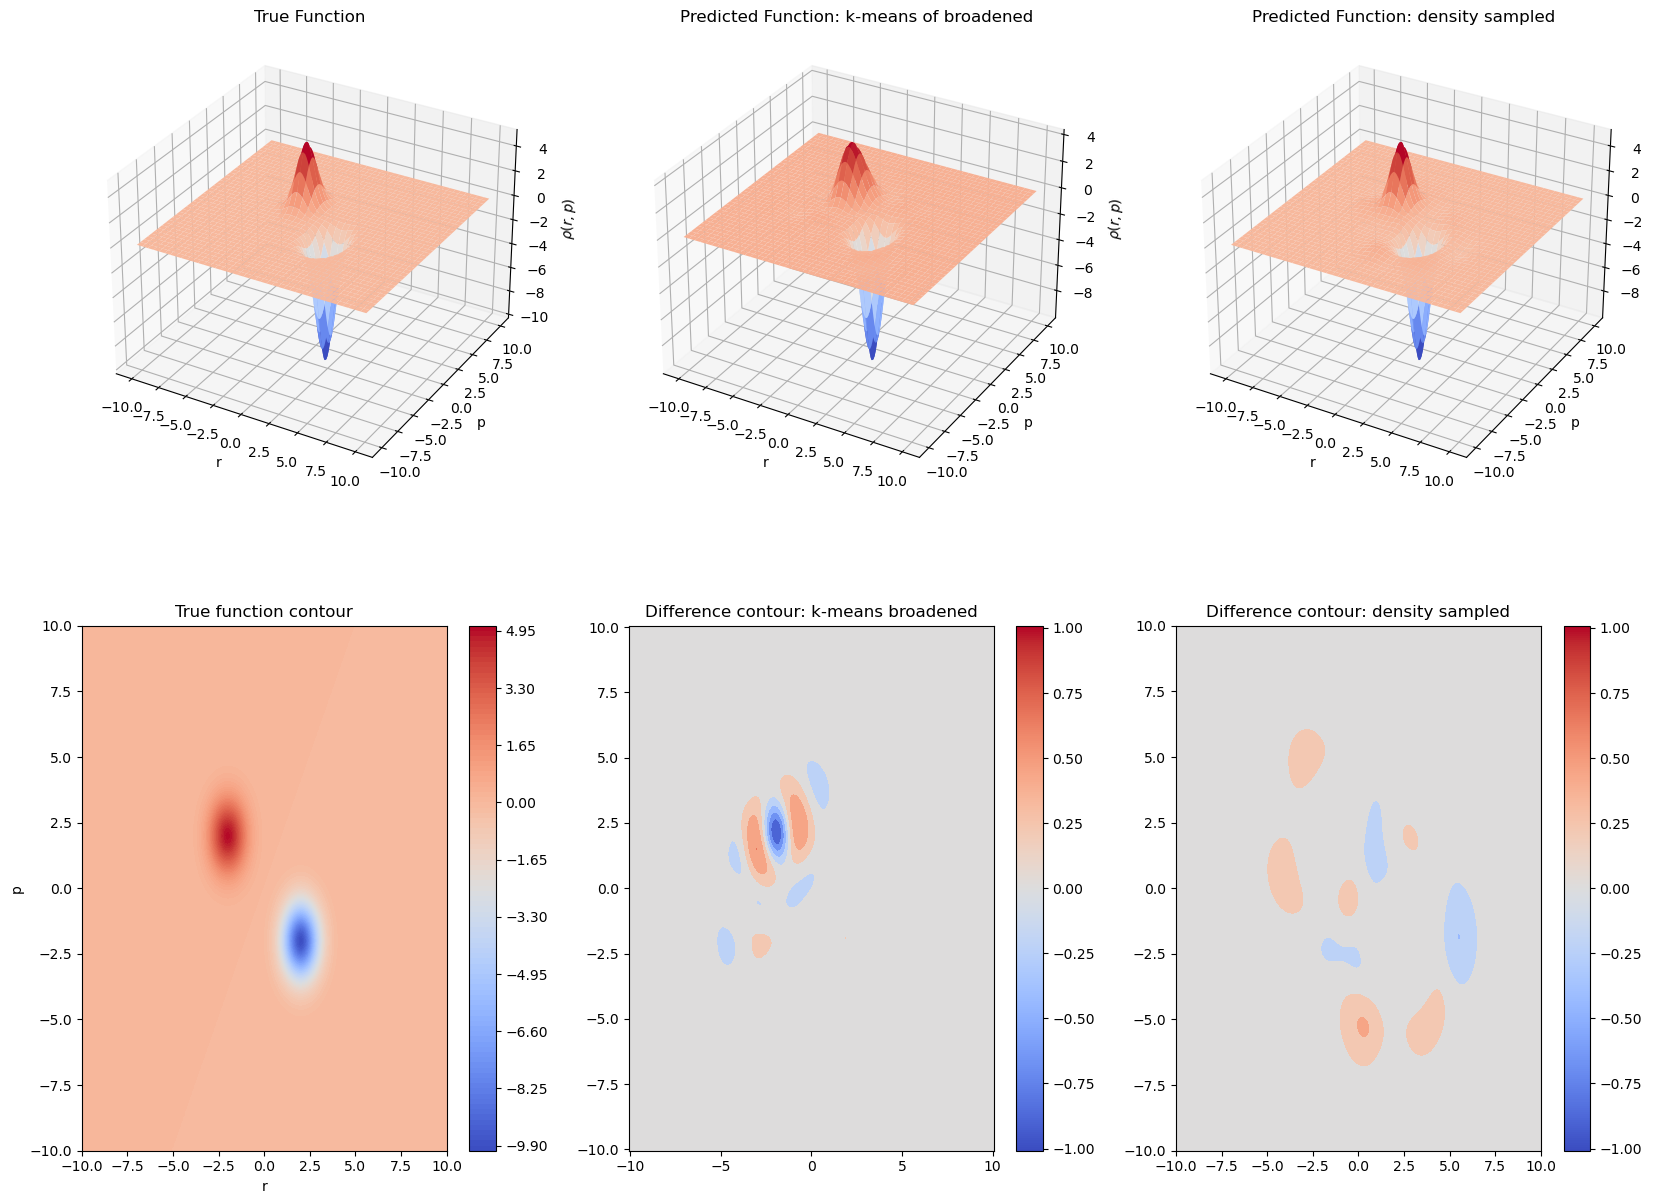

In [21]:
# Plot the true function
y_true_surface = y_true.reshape((n_grid, n_grid))
y_pred_surface0 = y_pred0.reshape((n_grid, n_grid))
y_pred_surface1 = y_pred1.reshape((n_grid, n_grid))

diff0 = y_pred_surface0 - y_true_surface
diff1 = y_pred_surface1 - y_true_surface
max0 = np.max( np.abs(diff0))
max1 = np.max( np.abs(diff1))

max = np.max([max0, max1])


# Plot the density maps of the true function and the GPR model
# Create a 3D plot of the true and predicted functions
fig = plt.figure(figsize=(20,15 ))
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
ax3 = fig.add_subplot(2,3, 3, projection='3d')
ax4 = fig.add_subplot(2,3, 4)
ax5 = fig.add_subplot(2,3, 5)
ax6 = fig.add_subplot(2,3, 6)


ax1.plot_surface(xx, yy, y_true_surface, cmap='coolwarm')
ax1.set_title('True Function')
ax1.set_xlabel('r')
ax1.set_ylabel('p')
ax1.set_zlabel(r'$\rho(r,p)$')

ax2.plot_surface(xx, yy, y_pred_surface0, cmap='coolwarm')
ax2.set_title('Predicted Function: k-means of broadened')
ax2.set_xlabel('r')
ax2.set_ylabel('p')
ax2.set_zlabel(r'$\rho(r,p)$')


ax3.plot_surface(xx, yy, y_pred_surface1, cmap='coolwarm')
ax3.set_title('Predicted Function: density sampled')
ax3.set_xlabel('r')
ax3.set_ylabel('p')
ax3.set_zlabel(r'$\rho(r,p)$')

# Plot the contour of the true function
cmap = plt.get_cmap('coolwarm')
contour = ax4.contourf(xx, yy, y_true_surface, 100, cmap=cmap)
ax4.set_title('True function contour')
ax4.set_xlabel('r')
ax4.set_ylabel('p')
plt.colorbar(mappable=contour, ax=ax4)

ncontours=10
dl = 2*max/(ncontours-1)

levels=[]
for i in range(ncontours):
    l=-max +i*dl
    levels.append(l)

pcm0 = ax5.pcolormesh(xx,yy,diff0,vmin=-max, vmax=max,cmap=cmap)
contour = ax5.contourf(xx, yy, diff0, levels=levels, cmap=cmap)
ax5.set_title('Difference contour: k-means broadened')
plt.colorbar(pcm0,ax=ax5)

contour = ax6.contourf(xx, yy, diff1, levels=levels, cmap=cmap)
ax6.set_title('Difference contour: density sampled')
plt.colorbar(pcm0,ax=ax6)



plt.savefig("biModalWeighted.png")
plt.show()


In [22]:
sigma0_surface = preds0.variance.numpy().reshape((n_grid, n_grid))
sigma1_surface = preds1.variance.numpy().reshape((n_grid, n_grid))

max0 = np.max( np.abs(sigma0_surface) )
max1 = np.max( np.abs(sigma1_surface))

max = np.max([max0, max1])


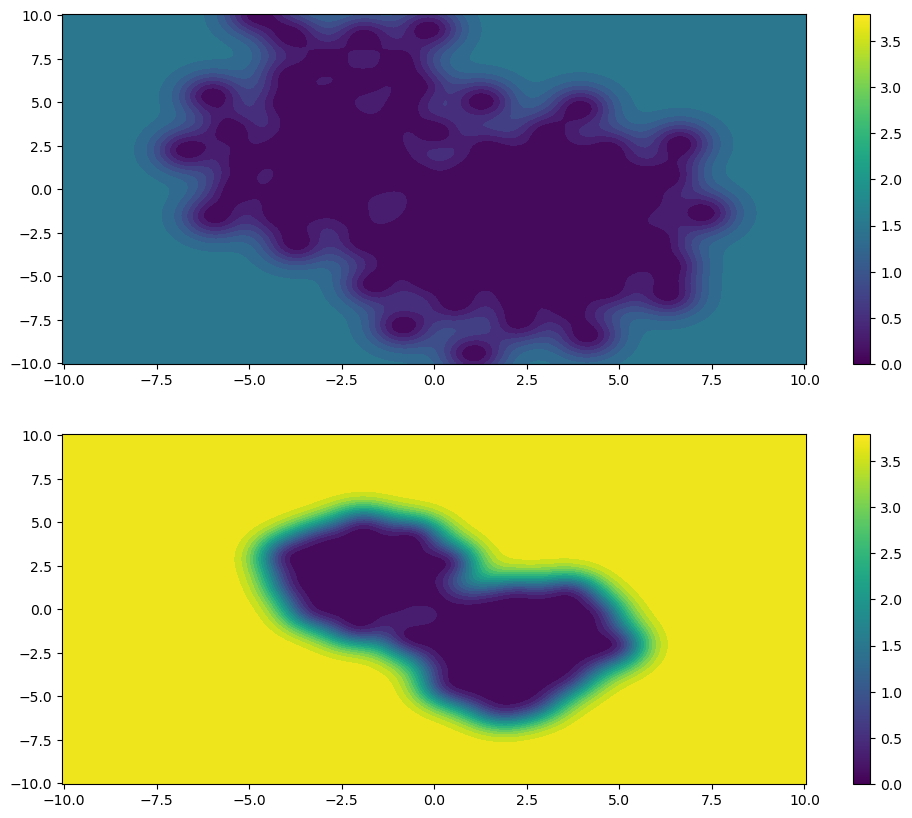

In [23]:
fig = plt.figure(figsize=(12,10 ))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

ncontours=20
dl = max/(ncontours-1)

levels=[]
for i in range(ncontours):
    l=i*dl
    levels.append(l)

cmap='RdBu_r'
pcm0 = ax1.pcolormesh(xx,yy,sigma0_surface, vmin=0, vmax = max)
contour = ax1.contourf(xx, yy, sigma0_surface, levels=levels)
ax5.set_title('Variance contour: k-means')
plt.colorbar(pcm0,ax=ax1)

pcm1 = ax2.pcolormesh(xx,yy,sigma1_surface, vmin=0, vmax=max)
contour = ax2.contourf(xx, yy, sigma1_surface, levels=levels)
ax5.set_title('Difference contour: sampled density')
plt.colorbar(pcm1,ax=ax2)
plt.show()


In [24]:
def weightFunction(x,p):
    return torch.pow(x,p)

In [25]:
maxV0 = torch.max(preds0.variance)
maxV1 = torch.max(preds1.variance)
print(' Maximum variances: model 0 = ', maxV0.numpy(), ' model 1 = ', maxV1.numpy())

w0 = weightFunction(1./preds0.variance, 0.5)
w1 = weightFunction(1./preds1.variance, 0.5)
norm = w0 + w1
weight1 = w1/norm
weight0 = w0/norm
weight_surface = weight1.numpy().reshape((n_grid, n_grid))
max=np.max(weight1.numpy())

 Maximum variances: model 0 =  1.4868854  model 1 =  3.786239


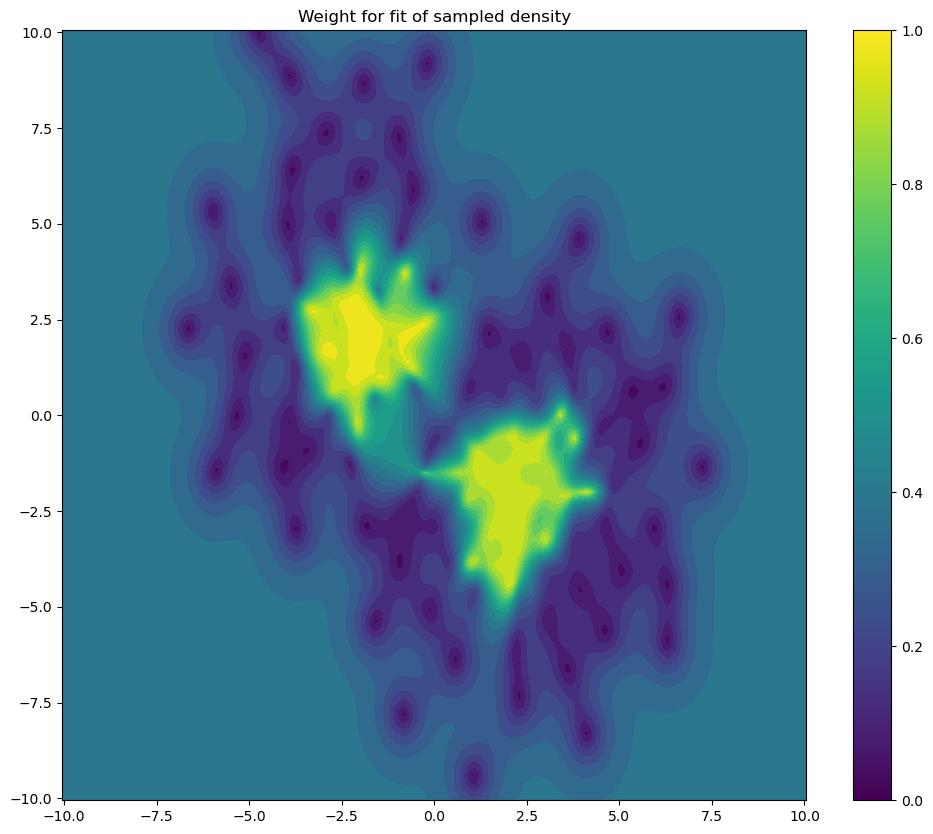

In [26]:
fig = plt.figure(figsize=(12,10 ))
ax1 = fig.add_subplot(1, 1, 1)
cmap='RdBu_r'
ncontours=20
#dl = 2*max/(ncontours-1)
dl = 1./(ncontours-1)

levels=[]
for i in range(ncontours):
    l=i*dl
    levels.append(l)

cmap='RdBu_r'
pcm0 = ax1.pcolormesh(xx,yy,weight_surface, vmin=0, vmax = 1)
contour = ax1.contourf(xx, yy, weight_surface, levels=levels)
ax1.set_title('Weight for fit of sampled density')
plt.colorbar(pcm0,ax=ax1)

In [27]:
avg_yp = (weight0*preds0.mean + weight1*preds1.mean).numpy()
#print(avg_yp.shape)

In [28]:
avg_yp_surface = avg_yp.reshape((n_grid, n_grid))
diff_avg = avg_yp_surface - y_true_surface
max = np.max( np.abs(diff_avg))
print(' Maximum difference of weighted average is ', max)


 Maximum difference of weighted average is  0.18887338723338032


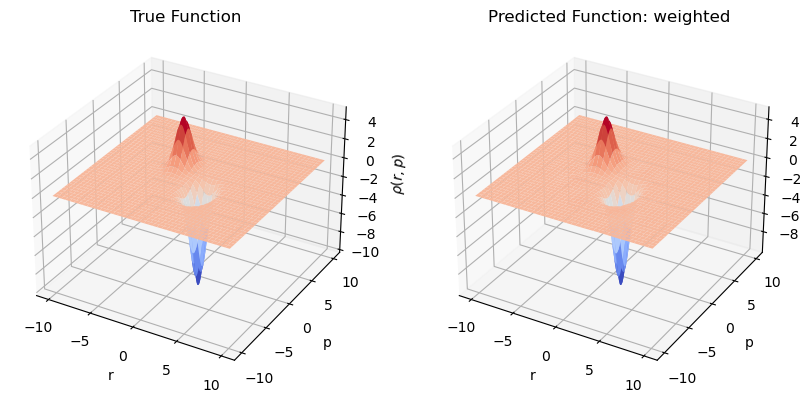

In [29]:
# Plot the density maps of the true function and the GPR model
# Create a 3D plot of the true and predicted functions
fig = plt.figure(figsize=(10,12))
ax1 = fig.add_subplot(1,2, 1, projection='3d')
ax2 = fig.add_subplot(1,2, 2, projection='3d')



ax1.plot_surface(xx, yy, y_true_surface, cmap='coolwarm')
ax1.set_title('True Function')
ax1.set_xlabel('r')
ax1.set_ylabel('p')
ax1.set_zlabel(r'$\rho(r,p)$')

ax2.plot_surface(xx, yy, avg_yp_surface, cmap='coolwarm')
ax2.set_title('Predicted Function: weighted')
ax2.set_xlabel('r')
ax2.set_ylabel('p')
ax2.set_zlabel(r'$\rho(r,p)$')
plt.show()

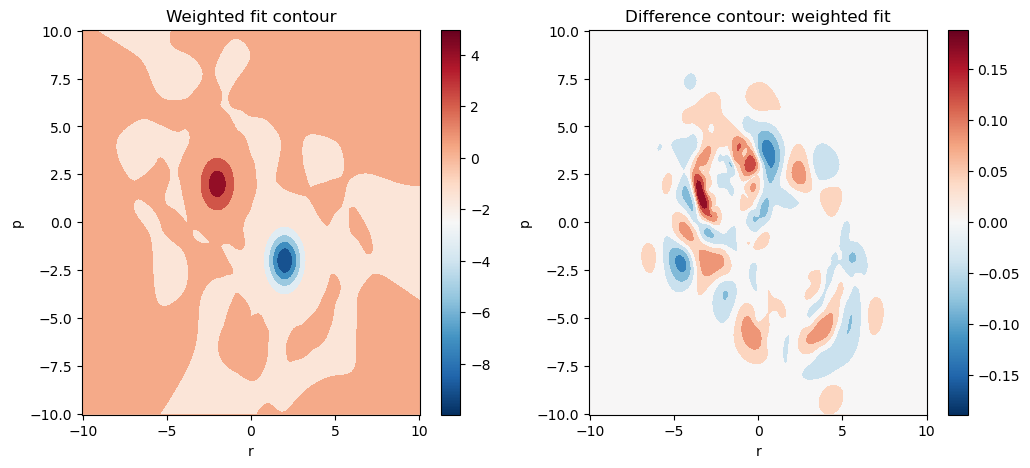

In [30]:
fig = plt.figure(figsize=(12,5 ))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1,2,2)
cmap='RdBu_r'
ncontours=20

pcm0 = ax1.pcolormesh(xx,yy,avg_yp_surface,cmap=cmap)
contour = ax1.contourf(xx, yy, avg_yp_surface, cmap=cmap)
ax1.set_xlabel('r')
ax1.set_ylabel('p')
ax1.set_title('Weighted fit contour')
plt.colorbar(pcm0,ax=ax1)


ncontours=10
dl = 2*max/(ncontours-1)

levels=[]
for i in range(ncontours):
    l=-max +i*dl
    levels.append(l)

pcm1 = ax2.pcolormesh(xx,yy,diff_avg,vmin=-max, vmax=max,cmap=cmap)
contour = ax2.contourf(xx, yy, diff_avg, levels=levels, cmap=cmap)
ax2.set_xlabel('r')
ax2.set_ylabel('p')
ax2.set_title('Difference contour: weighted fit')
plt.colorbar(pcm1,ax=ax2)
plt.show()

In [31]:
mse0 = np.mean((y_pred0 - y_true) ** 2)
mae0 = np.mean(np.abs(y_pred0 - y_true))
maxDifference0 = np.sqrt( np.max( (y_pred0 - y_true)**2 ) )

mse1 = np.mean((y_pred1 - y_true) ** 2)
mae1 = np.mean(np.abs(y_pred1 - y_true))
maxDifference1 = np.sqrt( np.max( (y_pred1 - y_true)**2 ) )

print('The mean squared error of models are: kmeans =', mse0, ' and density-sampled = ', mse1)
print('The mean absolute error of model are: ', mae0, ' and ', mae1)
print('The max difference of model are: ', maxDifference0, ' and ', maxDifference1,'\n')



mse = np.mean((avg_yp - y_true) ** 2)
mae = np.mean(np.abs(avg_yp - y_true))
maxDifference = np.sqrt( np.max( (avg_yp - y_true)**2 ) )

print(' Weighted prediction mse = ', mse)
print(' Weighted prediciton mae = ', mae)
print(' Weighted max difference = ', maxDifference)


The mean squared error of models are: kmeans = 0.004778678083609192  and density-sampled =  0.00296029535073484
The mean absolute error of model are:  0.023580800995863863  and  0.022477203249812176
The max difference of model are:  1.0085067132228431  and  0.36265633404599346 

 Weighted prediction mse =  0.0005876359681639849
 Weighted prediciton mae =  0.01244363100677776
 Weighted max difference =  0.18887338723338032
